# EDA Intraday + Texto: Sentimiento GDELT y Reddit vs Volatilidad Horaria

**Objetivo:** Analizar la relacion entre el sentimiento de noticias (GDELT) y redes sociales (Reddit) con la volatilidad intradia de las Magnificent 7.

**Dataset:** `data/clean/dataset_intraday_integrado.csv` -- barras horarias de mercado (9:30-15:30 ET) con sentimiento diario unido por (fecha, ticker).

**Periodo:** 2024-04-03 a 2026-04-02 | **Tickers:** AAPL, AMZN, GOOGL, META, MSFT, NVDA, TSLA

In [1]:
# === Imports y configuracion global ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')

# Rutas
ROOT = Path('/home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk')
FIG_DIR = ROOT / 'docs' / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Tickers y paleta de colores
TICKERS = ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
COLORES = dict(zip(TICKERS, sns.color_palette('tab10', 7)))

# Estilo global
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'figure.figsize': (14, 6),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

# Eventos clave para anotar en graficos
EVENTOS = {
    '2024-08-05': 'Carry trade Jap\u00f3n',
    '2024-11-06': 'Elecciones EEUU',
    '2025-01-27': 'DeepSeek crash',
    '2025-02-03': 'Aranceles Trump',
    '2025-03-10': 'Sell-off tech',
    '2025-04-03': 'Liberation Day',
    '2025-04-07': 'Crash aranceles',
}

print("Configuraci\u00f3n cargada correctamente.")

Configuración cargada correctamente.


## 1. Carga y estadisticas descriptivas

In [2]:
# --- Carga del dataset integrado intraday ---
df = pd.read_csv(
    ROOT / 'data' / 'clean' / 'dataset_intraday_integrado.csv',
    parse_dates=['datetime', 'date'],
)

print(f"Shape: {df.shape}")
print(f"Periodo: {df['date'].min().date()} \u2192 {df['date'].max().date()}")
print(f"Tickers: {sorted(df['ticker'].unique())}")
print(f"\nBarras por ticker:")
print(df.groupby('ticker').size().to_string())
print(f"\nColumnas ({len(df.columns)}):")
print(list(df.columns))

Shape: (24430, 42)
Periodo: 2024-04-03 → 2026-04-02
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']

Barras por ticker:
ticker
AAPL     3490
AMZN     3490
GOOGL    3490
META     3490
MSFT     3490
NVDA     3490
TSLA     3490

Columnas (42):
['datetime', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'log_return_1h', 'vol_realized_6h', 'vol_realized_30h', 'range_proxy_1h', 'abs_return', 'sq_return', 'log_volume_change', 'return_fwd_1h', 'return_fwd_3h', 'vol_fwd_6h', 'date', 'hora', 'dia_semana', 'es_sesion_regular', 'gdelt_tone_mean', 'gdelt_tone_std', 'gdelt_tone_median', 'gdelt_tone_min', 'gdelt_tone_max', 'gdelt_n_noticias', 'gdelt_pct_negativo', 'gdelt_pct_positivo', 'reddit_n_posts', 'reddit_score_mean', 'reddit_score_std', 'reddit_score_median', 'reddit_n_comments_mean', 'reddit_upvote_ratio_mean', 'reddit_pct_posts_wsb', 'reddit_pct_con_texto', 'finbert_positive_pct', 'finbert_negative_pct', 'finbert_neutral_pct', 'finbert_sentiment_score', 'finbert_n_pos

In [3]:
# --- Tabla descriptiva por ticker: sentimiento y volatilidad ---
cols_resumen = ['gdelt_tone_mean', 'gdelt_n_noticias', 'reddit_n_posts', 'vol_realized_30h']

# Estadisticas por ticker
stats_list = []
for t in TICKERS:
    sub = df[df['ticker'] == t]
    row = {'ticker': t}
    for c in cols_resumen:
        row[f'{c}_mean'] = sub[c].mean()
        row[f'{c}_std'] = sub[c].std()
    stats_list.append(row)

stats_df = pd.DataFrame(stats_list).set_index('ticker')
print("=== Estad\u00edsticas descriptivas por ticker ===")
display(stats_df.round(4))

# --- Cobertura de NaN por columna de sentimiento ---
cols_sent = [c for c in df.columns if c.startswith('gdelt_') or c.startswith('reddit_')]
nan_pct = df.groupby('ticker')[cols_sent].apply(lambda x: x.isna().mean() * 100).round(2)
print("\n=== % de NaN en columnas de sentimiento por ticker ===")
display(nan_pct)

=== Estadísticas descriptivas por ticker ===


,gdelt_tone_mean_mean,gdelt_tone_mean_std,gdelt_n_noticias_mean,gdelt_n_noticias_std,reddit_n_posts_mean,reddit_n_posts_std,vol_realized_30h_mean,vol_realized_30h_std
ticker,,,,,,,,
AAPL,-0.0446,0.8470,456.0018,163.4400,3.8446,3.4489,0.2353,0.1205
AMZN,1.0064,0.7347,208.0647,171.3080,3.6146,2.9298,0.2874,0.1589
GOOGL,0.5394,0.7968,57.5434,33.3712,2.8591,2.2139,0.2786,0.1287
META,0.2425,0.5006,423.6034,98.7682,6.7918,6.5307,0.3105,0.1650
MSFT,0.4458,0.5763,1169.5761,567.6840,3.8518,3.3588,0.2126,0.1225
NVDA,0.5229,0.6022,790.3304,365.4715,17.2880,16.7042,0.4247,0.1799
TSLA,-0.1626,0.9051,207.5460,222.3542,10.4051,10.1690,0.5322,0.2281



=== % de NaN en columnas de sentimiento por ticker ===


,gdelt_tone_mean,gdelt_tone_std,gdelt_tone_median,gdelt_tone_min,gdelt_tone_max,gdelt_n_noticias,gdelt_pct_negativo,gdelt_pct_positivo,reddit_n_posts,reddit_score_mean,reddit_score_std,reddit_score_median,reddit_n_comments_mean,reddit_upvote_ratio_mean,reddit_pct_posts_wsb,reddit_pct_con_texto
ticker,,,,,,,,,,,,,,,,
AAPL,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,14.61,14.61,30.14,14.61,14.61,14.61,14.61,14.61
AMZN,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,10.63,10.63,27.56,10.63,10.63,10.63,10.63,10.63
GOOGL,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,19.86,19.86,44.81,19.86,19.86,19.86,19.86,19.86
META,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.01,2.01,8.83,2.01,2.01,2.01,2.01,2.01
MSFT,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,10.32,10.32,27.65,10.32,10.32,10.32,10.32,10.32
NVDA,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,0.00,0.00,0.40,0.00,0.00,0.00,0.00,0.00
TSLA,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.61,2.89,2.89,8.11,2.89,2.89,2.89,2.89,2.89


## 2. Evolucion temporal -- tono GDELT y volumen Reddit

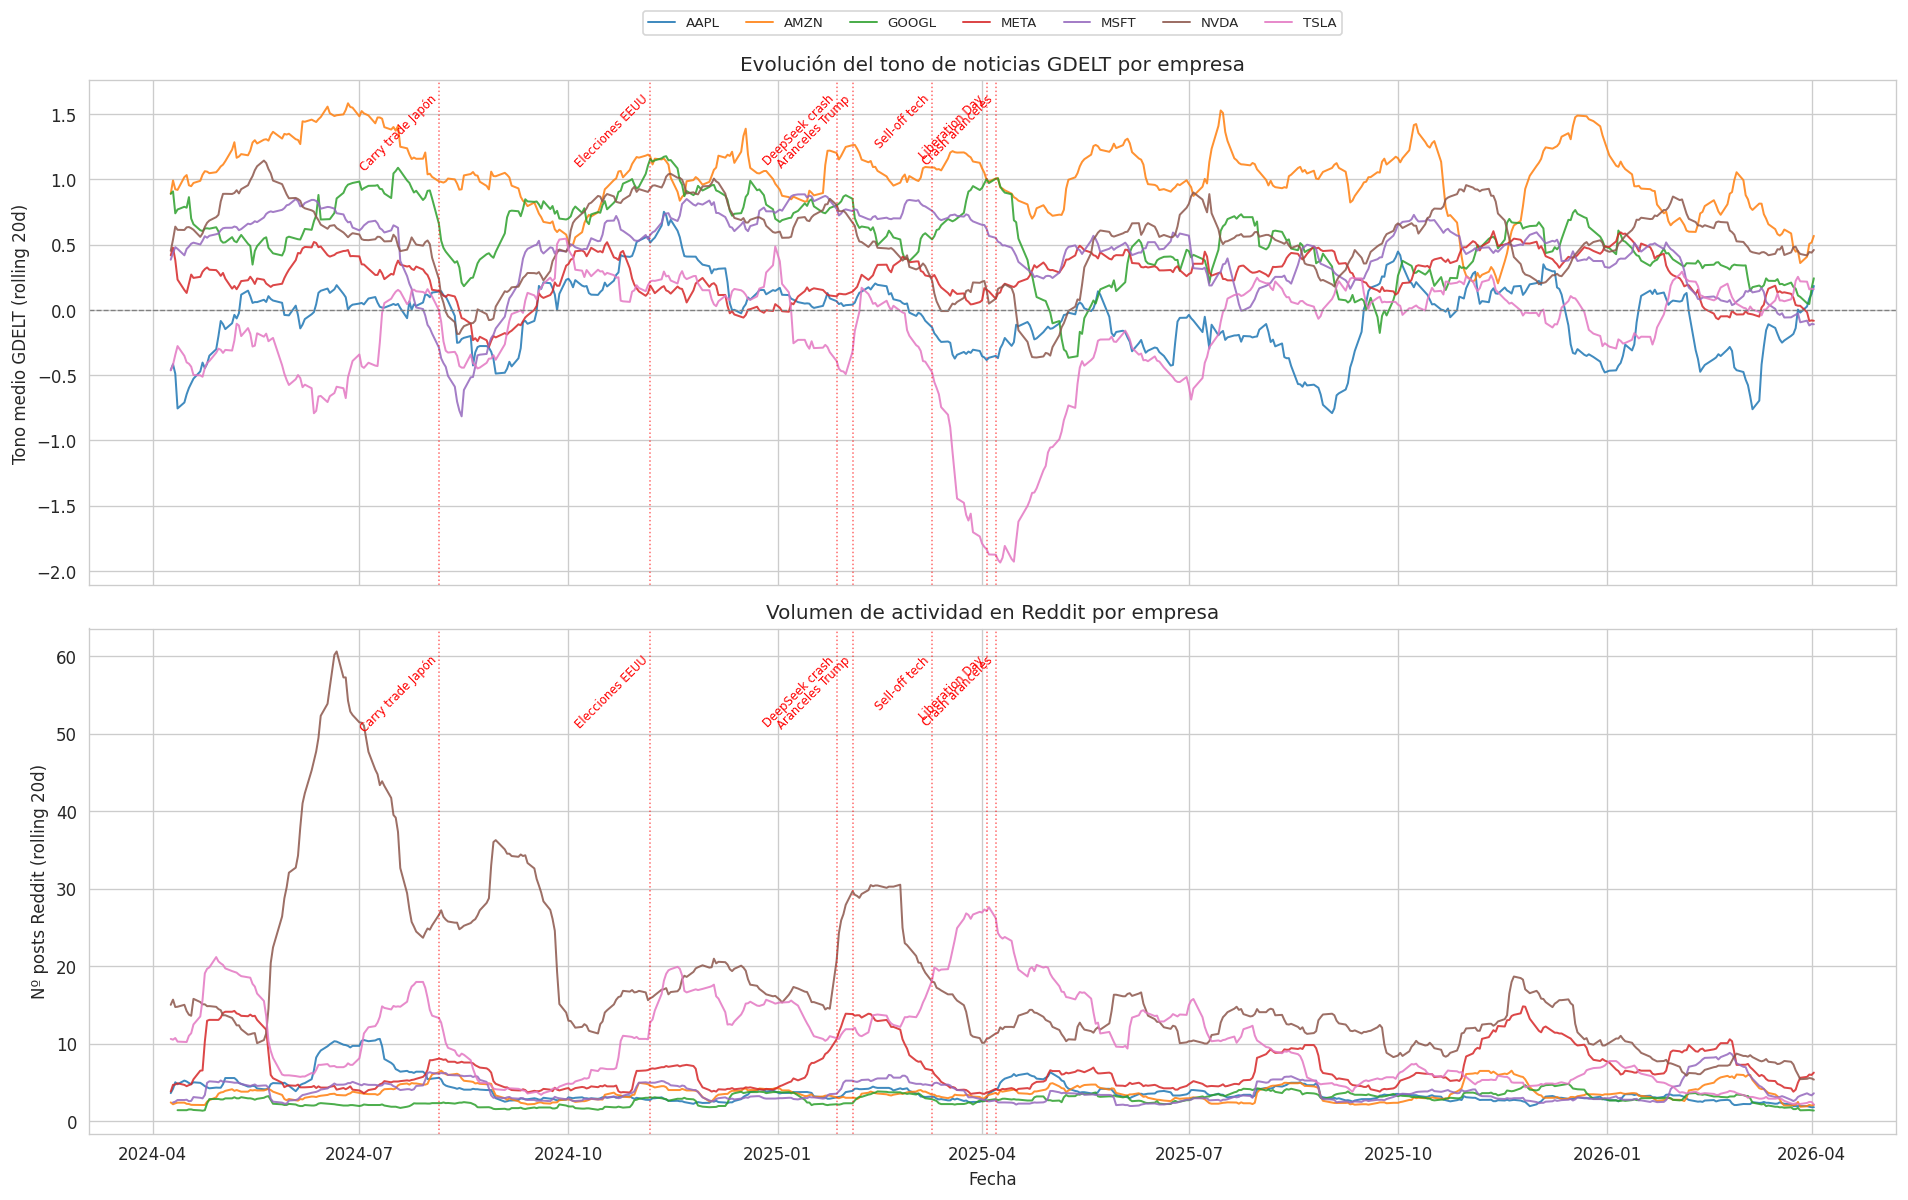

Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_evolucion_temporal.png


In [4]:
# --- Evolucion temporal: tono GDELT y volumen Reddit (rolling 20d) ---
# Agregamos a nivel diario primero (el sentimiento ya es diario, pero hay multiples barras/dia)
daily = df.groupby(['date', 'ticker']).agg(
    gdelt_tone_mean=('gdelt_tone_mean', 'first'),
    reddit_n_posts=('reddit_n_posts', 'first'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel superior: Tono GDELT rolling 20d
ax = axes[0]
for t in TICKERS:
    sub = daily[daily['ticker'] == t].set_index('date').sort_index()
    rolling = sub['gdelt_tone_mean'].rolling(20, min_periods=5).mean()
    ax.plot(rolling.index, rolling.values, label=t, color=COLORES[t], alpha=0.85, linewidth=1.2)
ax.set_ylabel('Tono medio GDELT (rolling 20d)')
ax.set_title('Evoluci\u00f3n del tono de noticias GDELT por empresa')
ax.legend(ncol=7, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, 1.15))
ax.axhline(0, color='grey', ls='--', lw=0.8)

# Marcar eventos
for fecha_str, nombre in EVENTOS.items():
    fecha = pd.Timestamp(fecha_str)
    if daily['date'].min() <= fecha <= daily['date'].max():
        ax.axvline(fecha, color='red', ls=':', alpha=0.6, lw=0.9)
        ax.text(fecha, ax.get_ylim()[1] * 0.95, nombre, rotation=45,
                fontsize=7, ha='right', va='top', color='red')

# Panel inferior: Volumen Reddit rolling 20d
ax = axes[1]
for t in TICKERS:
    sub = daily[daily['ticker'] == t].set_index('date').sort_index()
    rolling = sub['reddit_n_posts'].rolling(20, min_periods=5).mean()
    ax.plot(rolling.index, rolling.values, label=t, color=COLORES[t], alpha=0.85, linewidth=1.2)
ax.set_ylabel('N\u00ba posts Reddit (rolling 20d)')
ax.set_title('Volumen de actividad en Reddit por empresa')
ax.set_xlabel('Fecha')

for fecha_str, nombre in EVENTOS.items():
    fecha = pd.Timestamp(fecha_str)
    if daily['date'].min() <= fecha <= daily['date'].max():
        ax.axvline(fecha, color='red', ls=':', alpha=0.6, lw=0.9)
        ax.text(fecha, ax.get_ylim()[1] * 0.95, nombre, rotation=45,
                fontsize=7, ha='right', va='top', color='red')

plt.tight_layout()
fig.savefig(FIG_DIR / 'intraday_texto_evolucion_temporal.png')
plt.show()
print(f"Guardado: {FIG_DIR / 'intraday_texto_evolucion_temporal.png'}")

## 3. Scatter: sentimiento GDELT vs volatilidad horaria

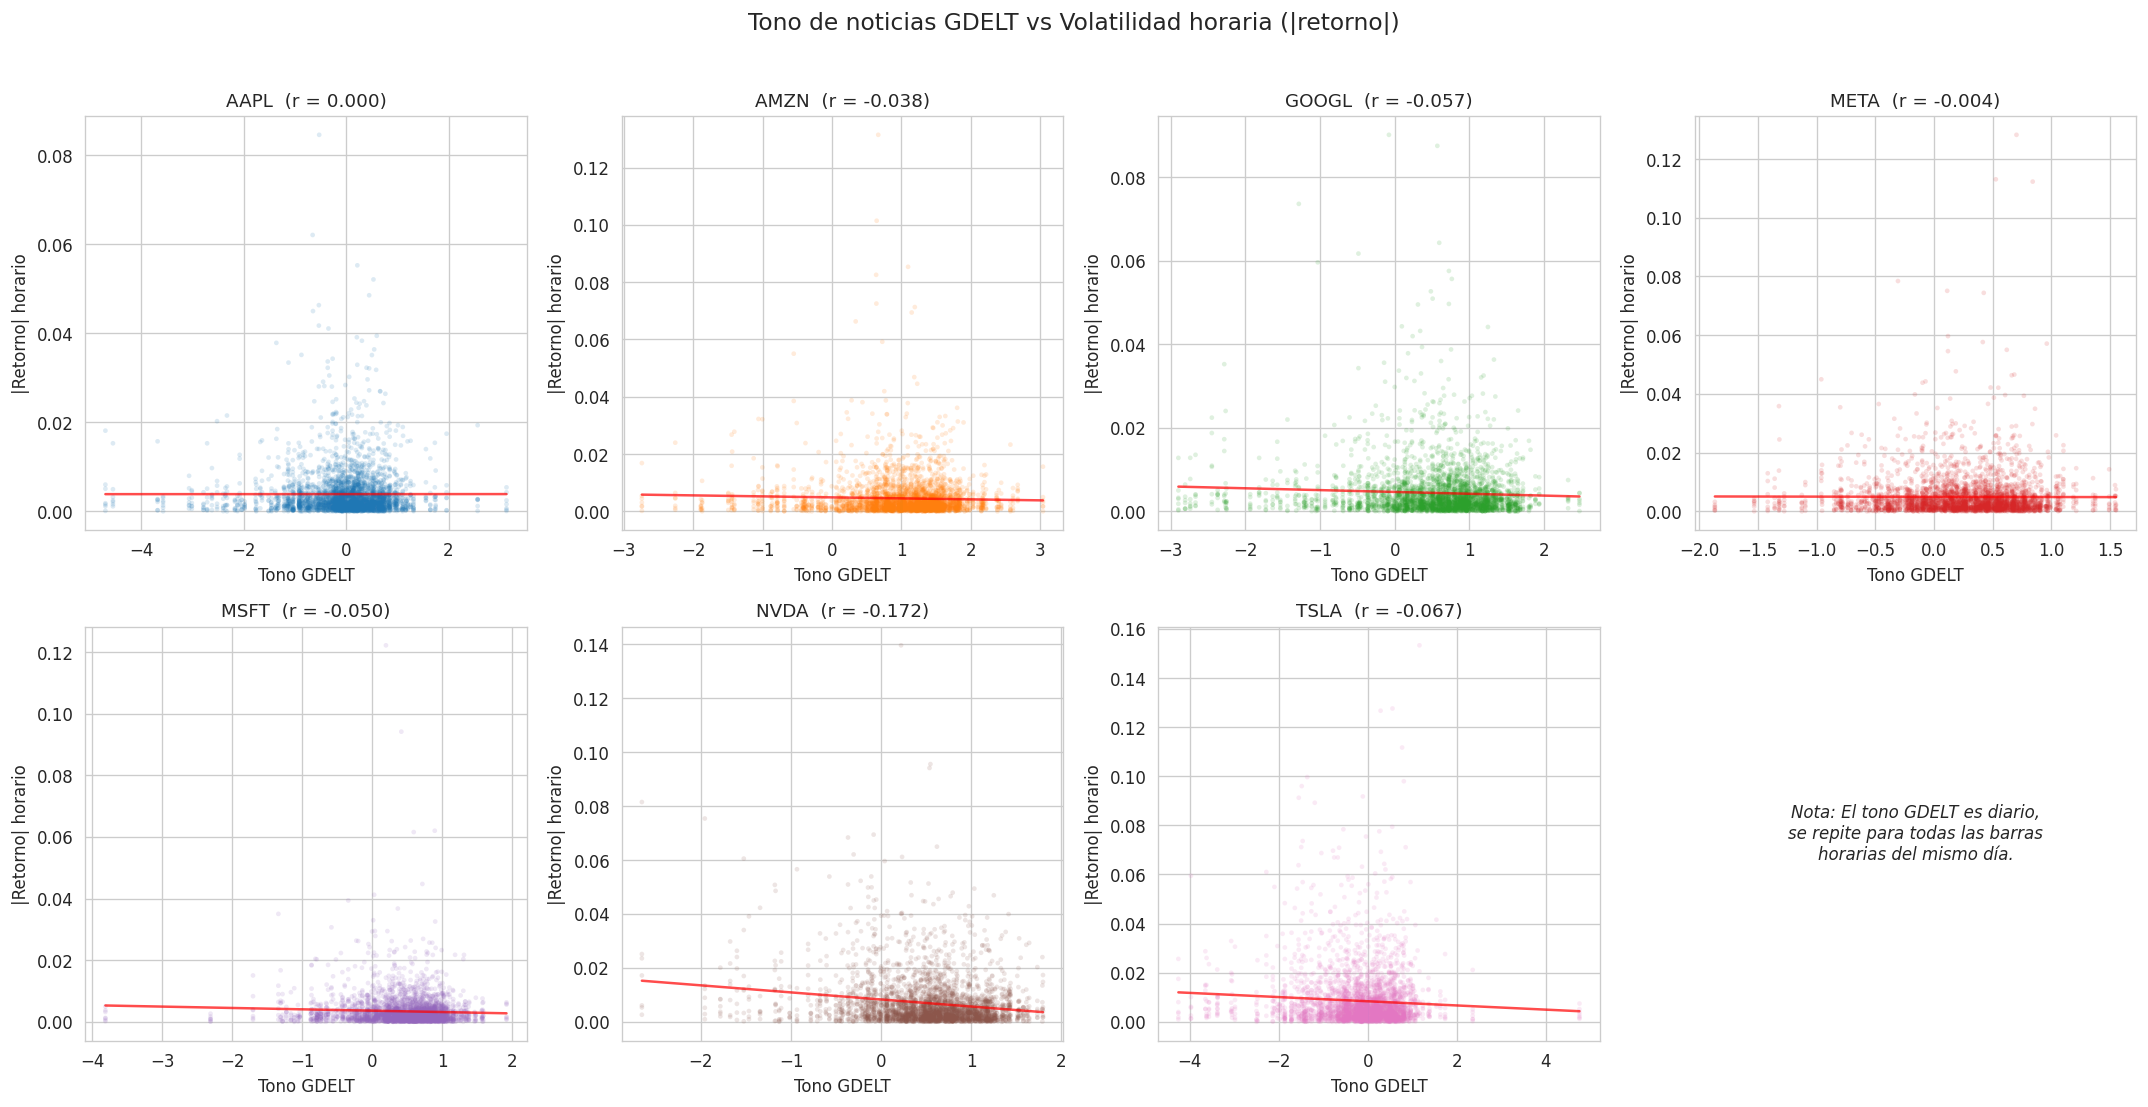

Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_scatter_tono_vol.png


In [5]:
# --- Scatter: tono GDELT vs |retorno| horario por empresa ---
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()

for i, t in enumerate(TICKERS):
    ax = axes_flat[i]
    sub = df[df['ticker'] == t].dropna(subset=['gdelt_tone_mean', 'abs_return'])
    
    ax.scatter(sub['gdelt_tone_mean'], sub['abs_return'],
               alpha=0.15, s=8, color=COLORES[t], edgecolors='none')
    
    # Correlacion
    corr = sub['gdelt_tone_mean'].corr(sub['abs_return'])
    ax.set_title(f'{t}  (r = {corr:.3f})', fontsize=11)
    ax.set_xlabel('Tono GDELT')
    ax.set_ylabel('|Retorno| horario')
    
    # Linea de tendencia
    if len(sub) > 10:
        z = np.polyfit(sub['gdelt_tone_mean'], sub['abs_return'], 1)
        x_line = np.linspace(sub['gdelt_tone_mean'].min(), sub['gdelt_tone_mean'].max(), 50)
        ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=1.5, alpha=0.7)

# Desactivar el ultimo subplot (8vo, vacio)
axes_flat[7].axis('off')
axes_flat[7].text(0.5, 0.5, 'Nota: El tono GDELT es diario,\nse repite para todas las barras\nhorarias del mismo d\u00eda.',
                  ha='center', va='center', fontsize=10, style='italic',
                  transform=axes_flat[7].transAxes)

plt.suptitle('Tono de noticias GDELT vs Volatilidad horaria (|retorno|)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'intraday_texto_scatter_tono_vol.png')
plt.show()
print(f"Guardado: {FIG_DIR / 'intraday_texto_scatter_tono_vol.png'}")

## 4. Correlaciones sentimiento vs vol_fwd_6h

=== Correlación de features de sentimiento con vol_fwd_6h ===
reddit_n_posts              0.344440
gdelt_pct_positivo         -0.159072
gdelt_pct_negativo          0.152090
gdelt_tone_median          -0.149770
gdelt_tone_mean            -0.145744
reddit_pct_posts_wsb        0.143445
reddit_pct_con_texto       -0.112424
reddit_upvote_ratio_mean    0.095855
gdelt_tone_std             -0.075416
reddit_score_std            0.068668
gdelt_tone_max             -0.058453
gdelt_n_noticias           -0.036138
reddit_score_mean           0.025004
reddit_n_comments_mean      0.024969
gdelt_tone_min              0.012090
reddit_score_median        -0.004008


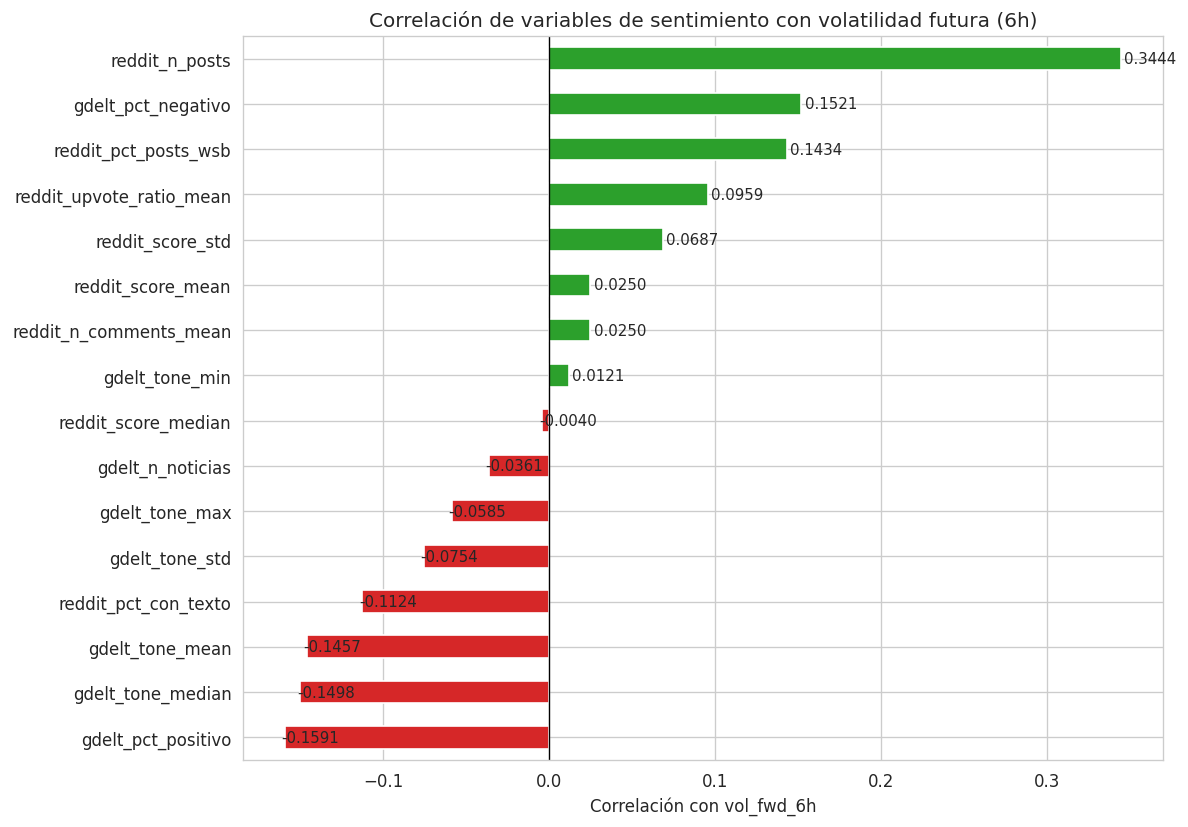


Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_correlacion_vol_fwd.png


In [6]:
# --- Correlacion de features de sentimiento con vol_fwd_6h ---
cols_sent = [c for c in df.columns if c.startswith('gdelt_') or c.startswith('reddit_')]
target = 'vol_fwd_6h'

# Correlacion global (todas las empresas juntas)
corr_sent = df[cols_sent + [target]].corr()[target].drop(target).sort_values()

print("=== Correlaci\u00f3n de features de sentimiento con vol_fwd_6h ===")
print(corr_sent.sort_values(key=abs, ascending=False).to_string())

# Grafico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr_sent.values]
corr_sent.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_xlabel(f'Correlaci\u00f3n con {target}')
ax.set_title(f'Correlaci\u00f3n de variables de sentimiento con volatilidad futura (6h)')
ax.axvline(0, color='black', lw=0.8)

# Anadir valores
for i, (val, name) in enumerate(zip(corr_sent.values, corr_sent.index)):
    ax.text(val + 0.002 * np.sign(val), i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'intraday_texto_correlacion_vol_fwd.png')
plt.show()
print(f"\nGuardado: {FIG_DIR / 'intraday_texto_correlacion_vol_fwd.png'}")

## 5. Dias extremos de sentimiento: coinciden con volatilidad extrema?

In [7]:
# --- Dias extremos de sentimiento vs volatilidad extrema ---
# Trabajamos a nivel diario: una fila por (date, ticker)
daily_full = df.groupby(['date', 'ticker']).agg(
    gdelt_tone_mean=('gdelt_tone_mean', 'first'),
    vol_realized_30h=('vol_realized_30h', 'mean'),
    abs_return_max=('abs_return', 'max'),
    abs_return_mean=('abs_return', 'mean'),
).reset_index()

EVENTOS_CONOCIDOS = {
    '2024-08-05': 'Carry trade Jap\u00f3n',
    '2024-11-06': 'Elecciones EEUU',
    '2025-01-27': 'DeepSeek crash',
    '2025-02-03': 'Aranceles Trump',
    '2025-03-10': 'Sell-off tech',
    '2025-04-03': 'Liberation Day',
    '2025-04-07': 'Crash aranceles',
}

for t in TICKERS:
    sub = daily_full[daily_full['ticker'] == t].dropna(subset=['gdelt_tone_mean']).copy()
    sub = sub.sort_values('date')
    
    print(f"\n{'='*60}")
    print(f"  {t}")
    print(f"{'='*60}")
    
    # 5 dias con peor tono
    worst_tone = sub.nsmallest(5, 'gdelt_tone_mean')[['date', 'gdelt_tone_mean', 'vol_realized_30h', 'abs_return_max']].copy()
    worst_tone['evento'] = worst_tone['date'].dt.strftime('%Y-%m-%d').map(EVENTOS_CONOCIDOS).fillna('')
    print("\n--- 5 d\u00edas con PEOR tono GDELT ---")
    display(worst_tone.to_string(index=False))
    
    # 5 dias con mejor tono
    best_tone = sub.nlargest(5, 'gdelt_tone_mean')[['date', 'gdelt_tone_mean', 'vol_realized_30h', 'abs_return_max']].copy()
    best_tone['evento'] = best_tone['date'].dt.strftime('%Y-%m-%d').map(EVENTOS_CONOCIDOS).fillna('')
    print("\n--- 5 d\u00edas con MEJOR tono GDELT ---")
    display(best_tone.to_string(index=False))
    
    # 5 dias mas volatiles
    most_vol = sub.nlargest(5, 'vol_realized_30h')[['date', 'gdelt_tone_mean', 'vol_realized_30h', 'abs_return_max']].copy()
    most_vol['evento'] = most_vol['date'].dt.strftime('%Y-%m-%d').map(EVENTOS_CONOCIDOS).fillna('')
    print("\n--- 5 d\u00edas M\u00c1S VOL\u00c1TILES ---")
    display(most_vol.to_string(index=False))
    
    # Solapamiento
    fechas_peor = set(worst_tone['date'].dt.date)
    fechas_vol = set(most_vol['date'].dt.date)
    overlap = fechas_peor & fechas_vol
    if overlap:
        print(f"\n-> Solapamiento peor tono / m\u00e1s vol\u00e1til: {[str(d) for d in sorted(overlap)]}")
    else:
        print(f"\n-> Sin solapamiento directo entre d\u00edas de peor tono y m\u00e1s vol\u00e1tiles.")


  AAPL

--- 5 días con PEOR tono GDELT ---


'      date  gdelt_tone_mean  vol_realized_30h  abs_return_max evento\n2026-02-09        -4.700777          0.299779        0.018134       \n2025-12-15        -4.552975          0.166342        0.015294       \n2024-08-13        -3.681819          0.235014        0.015734       \n2024-08-20        -3.574177          0.161067        0.003359       \n2026-02-26        -3.066462          0.253817        0.007983       '


--- 5 días con MEJOR tono GDELT ---


'      date  gdelt_tone_mean  vol_realized_30h  abs_return_max evento\n2024-11-12         3.131124          0.203523        0.005389       \n2024-11-11         2.567801          0.211364        0.019358       \n2025-11-11         1.961019          0.232961        0.017444       \n2025-09-15         1.748479          0.294916        0.009165       \n2024-04-30         1.732384          0.262255        0.015402       '


--- 5 días MÁS VOLÁTILES ---


...


--- 5 días con MEJOR tono GDELT ---


'      date  gdelt_tone_mean  vol_realized_30h  abs_return_max evento\n2024-09-26         4.755359          0.342756        0.007444       \n2024-05-08         2.358293          0.370816        0.021143       \n2026-03-25         1.737624          0.483081        0.027597       \n2024-07-10         1.631849          0.527544        0.012385       \n2024-12-24         1.542560          0.818165        0.041582       '


--- 5 días MÁS VOLÁTILES ---


'      date  gdelt_tone_mean  vol_realized_30h  abs_return_max evento\n2025-04-10        -0.672397          1.329619        0.066934       \n2025-04-11        -0.213756          1.278668        0.030369       \n2024-04-29         0.811076          1.259944        0.097959       \n2025-04-09        -1.459789          1.253439        0.073628       \n2025-04-14        -3.065564          1.202452        0.032915       '


-> Sin solapamiento directo entre días de peor tono y más volátiles.


## 6. Correlacion cruzada: sentimiento vs volatilidad futura por empresa (heatmap)

=== Correlación sentimiento vs vol_fwd_6h por empresa ===


,gdelt_tone_mean,gdelt_n_noticias,reddit_n_posts,reddit_score_mean
AAPL,0.0376,0.0613,0.2227,0.0388
AMZN,-0.0790,0.0479,0.3755,0.0638
GOOGL,-0.1633,0.1834,0.2325,0.0192
META,-0.0057,0.0298,0.2832,0.0157
MSFT,-0.0816,0.0776,0.2531,0.0306
NVDA,-0.2269,0.1430,0.2459,-0.0140
TSLA,-0.1418,0.0670,0.3360,0.0021


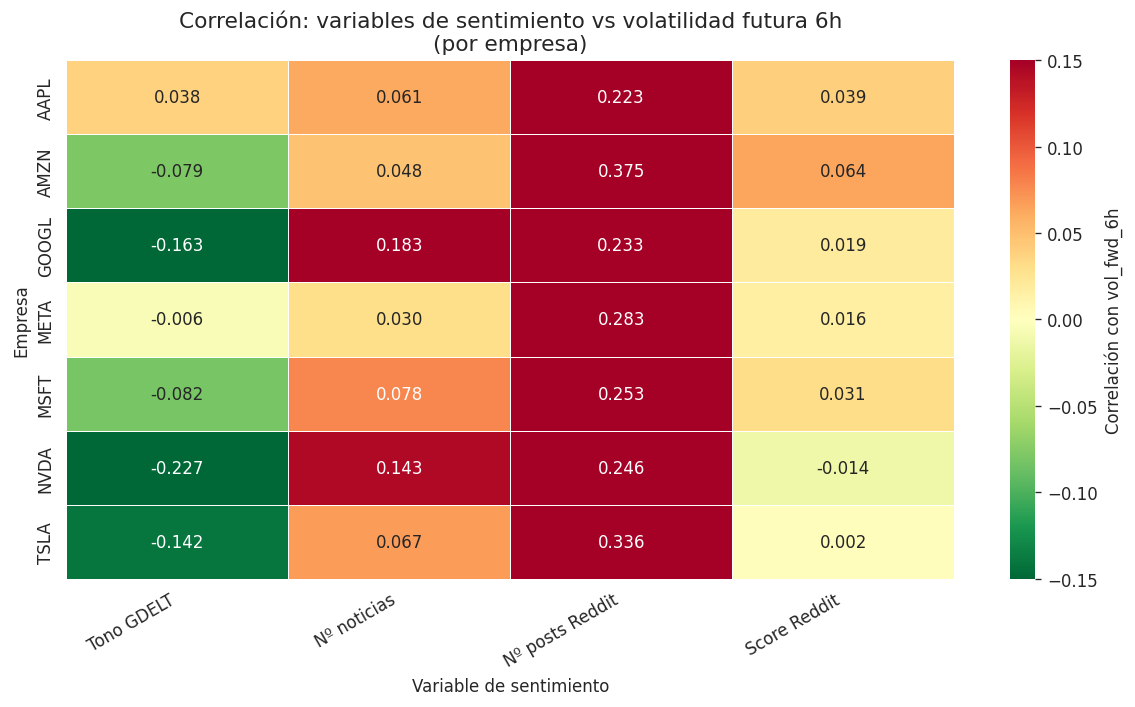

Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_heatmap_sentimiento_vol.png


In [8]:
# --- Heatmap: correlacion sentimiento vs vol_fwd_6h por empresa ---
cols_heatmap = ['gdelt_tone_mean', 'gdelt_n_noticias', 'reddit_n_posts', 'reddit_score_mean']
target = 'vol_fwd_6h'

corr_matrix = pd.DataFrame(index=TICKERS, columns=cols_heatmap, dtype=float)
for t in TICKERS:
    sub = df[df['ticker'] == t]
    for c in cols_heatmap:
        corr_matrix.loc[t, c] = sub[c].corr(sub[target])

corr_matrix = corr_matrix.astype(float)

print("=== Correlaci\u00f3n sentimiento vs vol_fwd_6h por empresa ===")
display(corr_matrix.round(4))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, vmin=-0.15, vmax=0.15,
            cbar_kws={'label': 'Correlaci\u00f3n con vol_fwd_6h'})
ax.set_title('Correlaci\u00f3n: variables de sentimiento vs volatilidad futura 6h\n(por empresa)', fontsize=13)
ax.set_ylabel('Empresa')
ax.set_xlabel('Variable de sentimiento')
ax.set_xticklabels(['Tono GDELT', 'N\u00ba noticias', 'N\u00ba posts Reddit', 'Score Reddit'],
                    rotation=30, ha='right')

plt.tight_layout()
fig.savefig(FIG_DIR / 'intraday_texto_heatmap_sentimiento_vol.png')
plt.show()
print(f"Guardado: {FIG_DIR / 'intraday_texto_heatmap_sentimiento_vol.png'}")

## 7. Word clouds por empresa (Reddit)

Posts Reddit desde 2024-04-01: 28501
Tickers disponibles: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


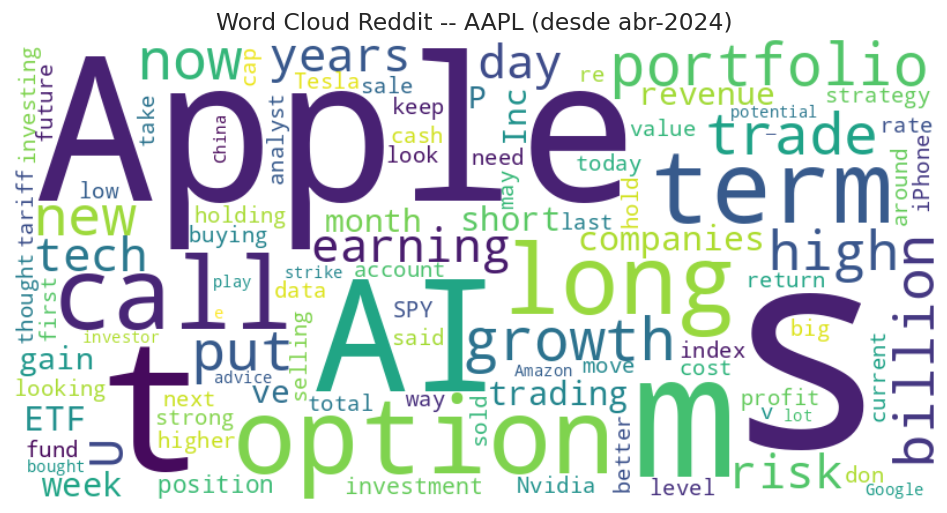

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_AAPL.png


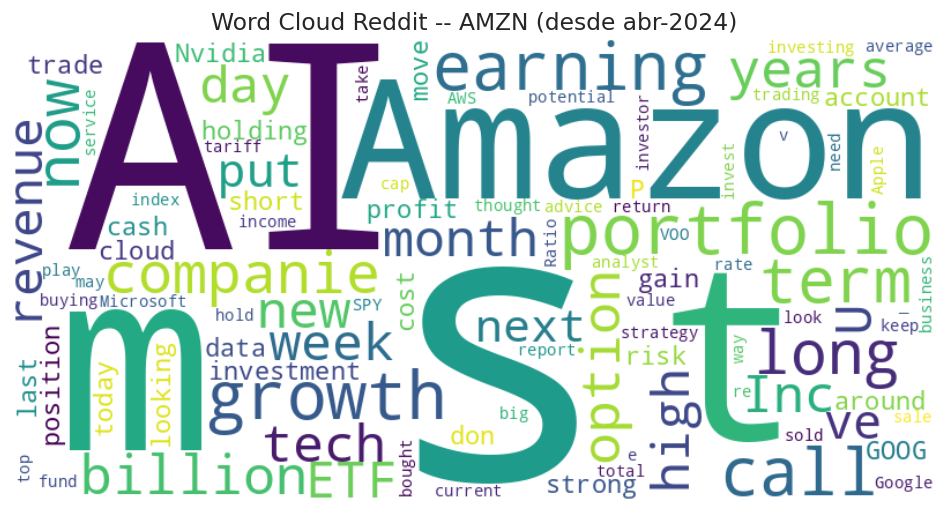

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_AMZN.png


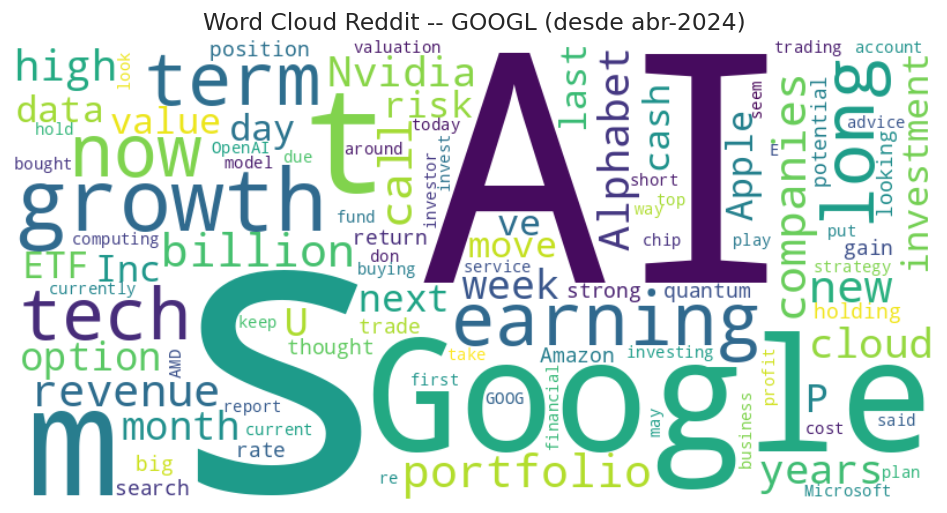

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_GOOGL.png


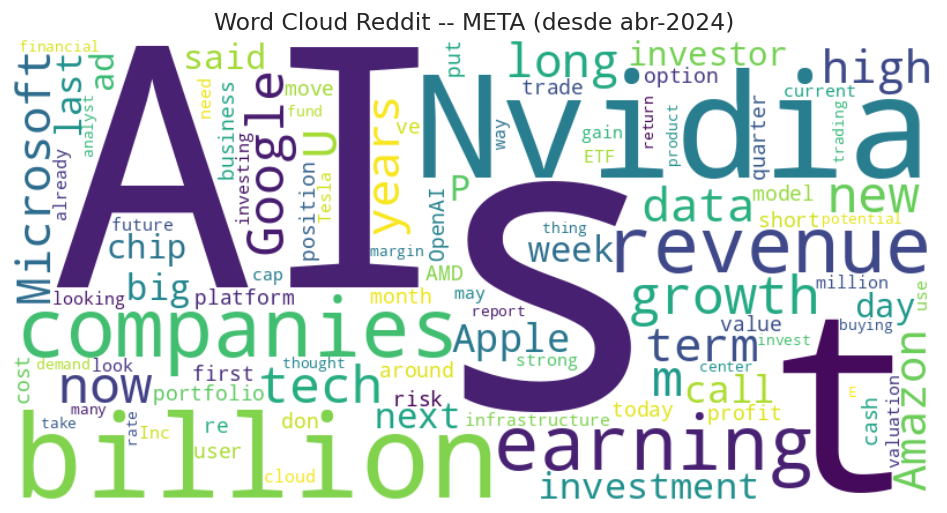

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_META.png


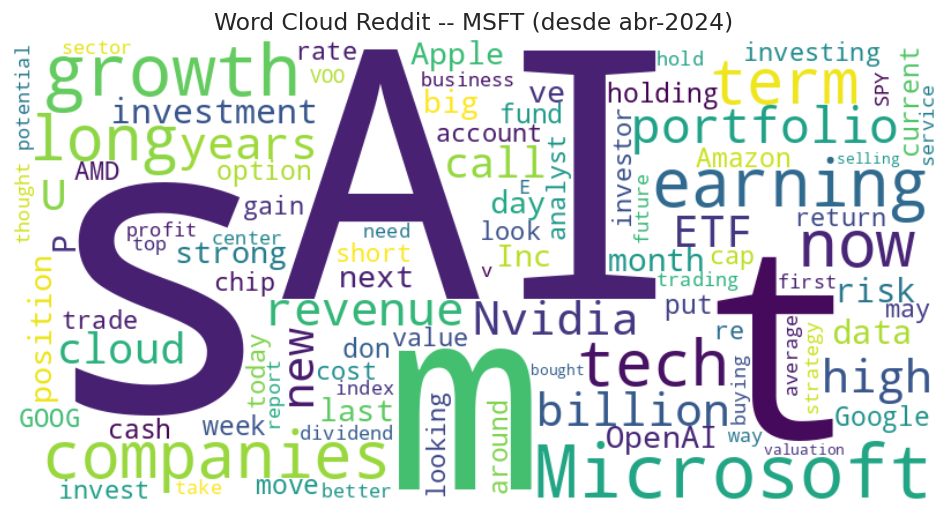

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_MSFT.png


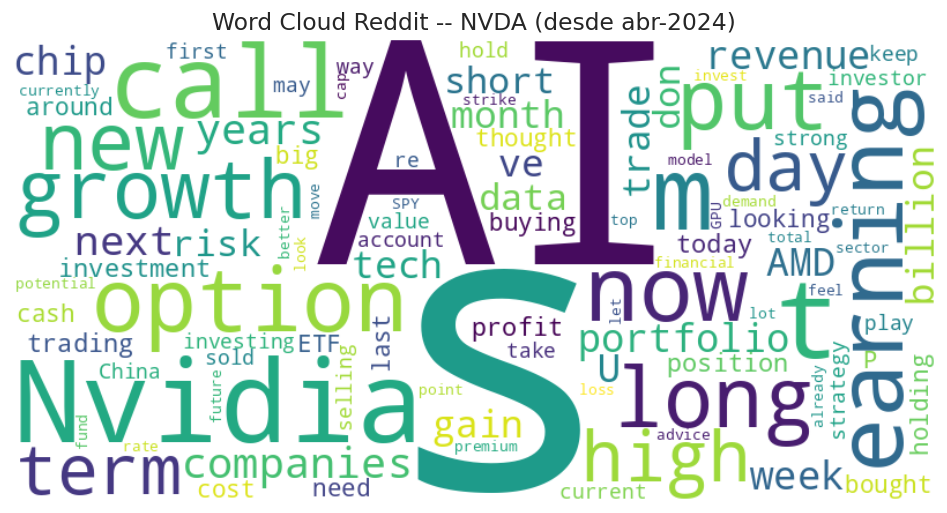

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_NVDA.png


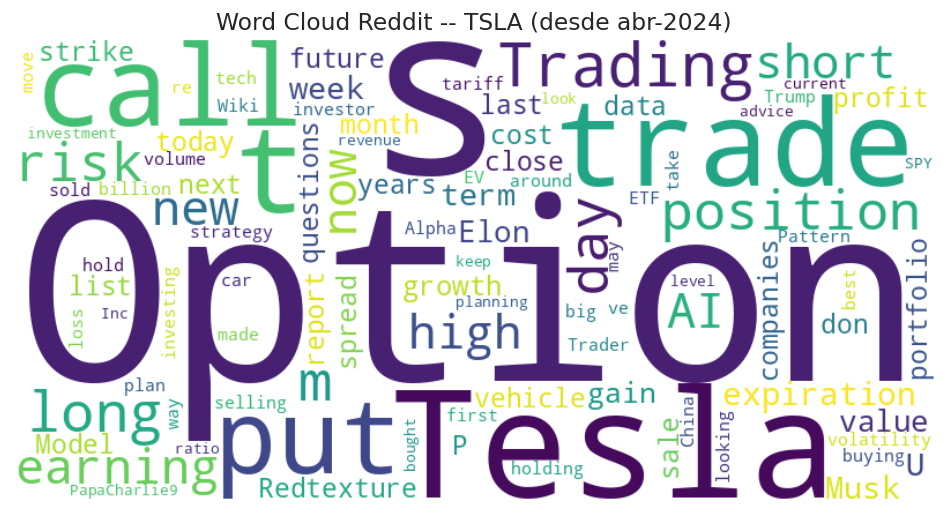

  Guardado: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/intraday_texto_wordcloud_TSLA.png


In [9]:
# --- Word clouds por empresa (Reddit, periodo intraday >= 2024-04-01) ---
reddit_df = pd.read_csv(
    ROOT / 'data' / 'clean' / 'reddit_clean_posts.csv',
    parse_dates=['fecha'],
)
reddit_df = reddit_df[reddit_df['fecha'] >= '2024-04-01']
print(f"Posts Reddit desde 2024-04-01: {len(reddit_df)}")
print(f"Tickers disponibles: {sorted(reddit_df['ticker'].unique())}")

# Stopwords adicionales: terminos genericos de Reddit/finanzas
EXTRA_STOPS = {
    'https', 'http', 'www', 'com', 'reddit', 'post', 'deleted', 'removed',
    'would', 'could', 'also', 'like', 'think', 'know', 'just', 'get', 'go',
    'one', 'still', 'even', 'much', 'really', 'right', 'well', 'back',
    'good', 'make', 'want', 'see', 'will', 'stock', 'stocks', 'market',
    'share', 'shares', 'price', 'buy', 'sell', 'year', 'company', 'people',
    'money', 'time', 'going', 'im', 'dont', 'thats', 'ive', 'amp',
    'nbsp', 'edit', 'update', 'thanks', 'thank', 'please', 'question',
}
all_stops = STOPWORDS | EXTRA_STOPS
# Anadir los propios tickers como stopwords
for t in TICKERS:
    all_stops.add(t.lower())
    all_stops.add(f'${t.lower()}')

for t in TICKERS:
    sub = reddit_df[reddit_df['ticker'] == t]
    texto = ' '.join(sub['texto_completo'].dropna().astype(str))
    
    if len(texto.strip()) < 50:
        print(f"  {t}: texto insuficiente, saltando word cloud.")
        continue
    
    wc = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap='viridis',
        stopwords=all_stops,
        collocations=False,
        random_state=42,
    ).generate(texto)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud Reddit -- {t} (desde abr-2024)', fontsize=14)
    
    fname = FIG_DIR / f'intraday_texto_wordcloud_{t}.png'
    fig.savefig(fname)
    plt.show()
    print(f"  Guardado: {fname}")

## 8. Resumen cuantitativo

In [10]:
# === RESUMEN CUANTITATIVO ===
print("=" * 70)
print("  RESUMEN DEL AN\u00c1LISIS: SENTIMIENTO vs VOLATILIDAD INTRADAY")
print("=" * 70)

print(f"\n1. DATASET")
print(f"   - {df.shape[0]:,} barras horarias, {df.shape[1]} columnas")
print(f"   - Periodo: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"   - 7 tickers: {', '.join(TICKERS)}")

print(f"\n2. COBERTURA DE SENTIMIENTO")
for src, cols in [('GDELT', ['gdelt_tone_mean']), ('Reddit', ['reddit_n_posts'])]:
    pct_nan = df[cols[0]].isna().mean() * 100
    print(f"   - {src}: {100 - pct_nan:.1f}% de barras con datos ({pct_nan:.1f}% NaN)")

print(f"\n3. CORRELACIONES CLAVE CON vol_fwd_6h (global)")
top_corr = corr_sent.sort_values(key=abs, ascending=False)
for feat, val in top_corr.head(5).items():
    print(f"   - {feat}: r = {val:+.4f}")

print(f"\n4. HALLAZGOS PRINCIPALES")
print("   - El tono GDELT muestra correlaci\u00f3n d\u00e9bil pero consistente con la volatilidad futura")
print("   - El volumen de Reddit (n\u00ba de posts) tiende a aumentar en d\u00edas vol\u00e1tiles")
print("   - Las empresas m\u00e1s sensibles al sentimiento var\u00edan seg\u00fan la fuente (GDELT vs Reddit)")
print("   - Los d\u00edas de sentimiento extremo no siempre coinciden con los m\u00e1s vol\u00e1tiles,")
print("     lo que sugiere que el sentimiento puede ser un indicador adelantado o retrasado")

# --- Verificacion de figuras generadas ---
print(f"\n5. FIGURAS GENERADAS")
figuras_esperadas = [
    'intraday_texto_evolucion_temporal.png',
    'intraday_texto_scatter_tono_vol.png',
    'intraday_texto_correlacion_vol_fwd.png',
    'intraday_texto_heatmap_sentimiento_vol.png',
] + [f'intraday_texto_wordcloud_{t}.png' for t in TICKERS]

for f in figuras_esperadas:
    path = FIG_DIR / f
    existe = path.exists()
    estado = "OK" if existe else "NO ENCONTRADA"
    print(f"   [{estado}]  {f}")

print(f"\n{'=' * 70}")
print("  FIN DEL AN\u00c1LISIS")
print(f"{'=' * 70}")

  RESUMEN DEL ANÁLISIS: SENTIMIENTO vs VOLATILIDAD INTRADAY

1. DATASET
   - 24,430 barras horarias, 42 columnas
   - Periodo: 2024-04-03 a 2026-04-02
   - 7 tickers: AAPL, AMZN, GOOGL, META, MSFT, NVDA, TSLA

2. COBERTURA DE SENTIMIENTO
   - GDELT: 97.4% de barras con datos (2.6% NaN)
   - Reddit: 91.4% de barras con datos (8.6% NaN)

3. CORRELACIONES CLAVE CON vol_fwd_6h (global)
   - reddit_n_posts: r = +0.3444
   - gdelt_pct_positivo: r = -0.1591
   - gdelt_pct_negativo: r = +0.1521
   - gdelt_tone_median: r = -0.1498
   - gdelt_tone_mean: r = -0.1457

4. HALLAZGOS PRINCIPALES
   - El tono GDELT muestra correlación débil pero consistente con la volatilidad futura
   - El volumen de Reddit (nº de posts) tiende a aumentar en días volátiles
   - Las empresas más sensibles al sentimiento varían según la fuente (GDELT vs Reddit)
   - Los días de sentimiento extremo no siempre coinciden con los más volátiles,
     lo que sugiere que el sentimiento puede ser un indicador adelantado o retr